# Recipe Improvement Ranking - Linear Regression


## 1. Imports

In [10]:
from pathlib import Path
import csv
import json
import random
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from IPython.display import display


## 2. Configuration


In [11]:
DATA_PATH = Path("../data/merged_vector_dataset.csv")
RESULTS_ROOT = Path("../results/recipe_improvement_ranking_linear")
MODEL_KIND = "linear"
NUM_FOLDS = 5
USE_FIXED_SEED = False
RANDOM_SEED = 7
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 30
BATCH_SIZE = 4096
MAX_TRAIN_TARGETS_PER_SOURCE = 16
MAX_TEST_TARGETS_PER_SOURCE = None
HIDDEN_DIM_1 = 64
HIDDEN_DIM_2 = 32
DROPOUT = 0.1

AST_FEATURE_COLUMNS = [
    "total_input_bits",
    "total_output_bits",
    "total_register_bits",
    "total_logic_operator_bits",
    "total_adder_sub_bits",
    "total_multiplier_bits",
    "total_comparator_bits",
    "total_multiplexer_bits",
    "total_shift_bits",
    "total_division_bits",
    "total_memory_write_addr_bits",
    "total_memory_write_addr_width",
    "total_memory_read_addr_bits",
    "total_memory_read_addr_width",
    "average_tree_depth",
    "average_wire_width",
]

NUMERIC_CONFIG_COLUMNS = [
    "clock_period_ns_cfg",
    "max_fanout_cfg",
    "max_transition_ns_cfg",
    "max_capacitance_ff_cfg",
    "fanout_load_cfg",
]

CATEGORICAL_CONFIG_COLUMNS = ["abc_fast_cfg", "flow_mode"]
QOR_COLUMNS = ["worst_slack_ns", "total_negative_slack_ns"]
DELTA_TARGET_COLUMNS = ["delta_worst_slack_ns", "delta_total_negative_slack_ns"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if USE_FIXED_SEED:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)
    print("Using fixed random seed:", RANDOM_SEED)
else:
    print("Using non-deterministic random behavior")


print("Model kind:", MODEL_KIND)
print("Using device:", DEVICE)


Using non-deterministic random behavior
Model kind: linear
Using device: cpu


## 3. Load Data


In [12]:
with DATA_PATH.open("r", newline="") as f:
    rows = list(csv.DictReader(f))

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
run_num = 1
while True:
    RUN_DIR = RESULTS_ROOT / f"run_{run_num:03d}"
    if not RUN_DIR.exists():
        RUN_DIR.mkdir()
        break
    run_num += 1

rows_df = pd.DataFrame(rows)
AST_FEATURE_COLUMNS = [
    col for col in AST_FEATURE_COLUMNS
    if col in rows_df.columns and rows_df[col].astype(str).str.strip().ne("").any()
]
if not AST_FEATURE_COLUMNS:
    raise ValueError("No AST feature columns were found in the merged dataset.")

print(f"Loaded {len(rows)} rows from {DATA_PATH}")
print(f"Using AST feature columns: {AST_FEATURE_COLUMNS}")
print(f"Saving run artifacts to {RUN_DIR.resolve()}")
rows[:2]


Loaded 13536 rows from ..\data\merged_vector_dataset.csv
Using AST feature columns: ['total_input_bits', 'total_output_bits', 'total_register_bits', 'total_logic_operator_bits', 'total_adder_sub_bits', 'total_multiplier_bits', 'total_comparator_bits', 'total_multiplexer_bits', 'total_shift_bits', 'total_division_bits', 'total_memory_write_addr_bits', 'total_memory_write_addr_width', 'total_memory_read_addr_bits', 'total_memory_read_addr_width', 'average_tree_depth', 'average_wire_width']
Saving run artifacts to C:\Users\DeAndre\Documents\Spring 2026\nndl\final_project\PPA-Estimation-Project\modeling\results\recipe_improvement_ranking_linear\run_004


[{'design_name': 'i2c',
  'design_id': 'iwls05_0006',
  'recipe_id': 'abcfast_clk0p1_fo16_tr0p16_cap100_fload1',
  'flow_mode': 'full',
  'total_input_bits': '19',
  'total_output_bits': '14',
  'total_register_bits': '128',
  'total_logic_operator_bits': '186',
  'total_adder_sub_bits': '19',
  'total_multiplier_bits': '0',
  'total_comparator_bits': '1350',
  'total_multiplexer_bits': '514',
  'total_shift_bits': '0',
  'total_division_bits': '0',
  'total_memory_write_addr_bits': '0',
  'total_memory_write_addr_width': '0',
  'total_memory_read_addr_bits': '0',
  'total_memory_read_addr_width': '0',
  'average_tree_depth': '6.401617250673854',
  'average_wire_width': '4.707949790794979',
  'worst_slack_ns': '-0.380054',
  'total_negative_slack_ns': '-31.437371',
  'run_utc': '2026-04-06T14:32:37+00:00',
  'run_id': 'i2c__abcfast_clk0p1_fo16_tr0p16_cap100_fload1',
  'top_module': 'i2c_master_top',
  'clock_port': 'wb_clk_i',
  'abc_fast_cfg': 'True',
  'clock_period_ns_cfg': '0.1',
 

## 4. Base Table and Design Split


In [13]:
keep_cols = ["design_name", "design_id", "recipe_id"] + AST_FEATURE_COLUMNS + NUMERIC_CONFIG_COLUMNS + CATEGORICAL_CONFIG_COLUMNS + QOR_COLUMNS
rows_df = pd.DataFrame(rows)[keep_cols].copy()

for col in AST_FEATURE_COLUMNS + NUMERIC_CONFIG_COLUMNS + QOR_COLUMNS:
    rows_df[col] = pd.to_numeric(rows_df[col], errors="coerce").fillna(0.0).astype(np.float32)

rows_df["design_name"] = rows_df["design_name"].astype(str)
rows_df["recipe_id"] = rows_df["recipe_id"].astype(str)

design_groups = rows_df["design_name"].to_numpy()
unique_designs = sorted(rows_df["design_name"].unique().tolist())

if len(unique_designs) < 2:
    raise ValueError("Need at least 2 designs for GroupKFold")

n_splits = min(NUM_FOLDS, len(unique_designs))
cv = GroupKFold(n_splits=n_splits)
fold_splits = list(cv.split(rows_df, groups=design_groups))

fold_rows = []
for fold_number, (train_idx, test_idx) in enumerate(fold_splits, start=1):
    train_designs = sorted(rows_df.iloc[train_idx]["design_name"].unique().tolist())
    test_designs = sorted(rows_df.iloc[test_idx]["design_name"].unique().tolist())
    fold_rows.append({
        "fold": fold_number,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_design_count": len(train_designs),
        "test_design_count": len(test_designs),
        "train_designs": ", ".join(train_designs),
        "test_designs": ", ".join(test_designs),
    })

fold_info_table = pd.DataFrame(fold_rows)
print("Split mode: GroupKFold by design_name")
print("Using folds:", n_splits)
print("Total base rows:", len(rows_df))
print("Total designs:", len(unique_designs))
display(fold_info_table)


Split mode: GroupKFold by design_name
Using folds: 5
Total base rows: 13536
Total designs: 47


,fold,train_rows,test_rows,train_design_count,test_design_count,train_designs,test_designs
0,1,10656,2880,37,10,"i2c, s1196a, s1196b, s1238, s1238a, s13207a, s...","s1196, s13207, s15850, s349, s38584a, s510, s6..."
1,2,10656,2880,37,10,"s1196, s1196a, s1196b, s1238, s13207, s13207a,...","i2c, s1238a, s1488, s344, s38584, s444, s5378a..."
2,3,10944,2592,38,9,"i2c, s1196, s1196a, s1196b, s1238a, s13207, s1...","s1238, s1423a, s298, s38417, s420, s5378, s820..."
3,4,10944,2592,38,9,"i2c, s1196, s1196a, s1238, s1238a, s13207, s13...","s1196b, s1423, s27, s382, s400, s526a, s820, s..."
4,5,10944,2592,38,9,"i2c, s1196, s1196b, s1238, s1238a, s13207, s14...","s1196a, s13207a, s15850a, s35932, s386, s526, ..."


## 5. Helper Functions


In [14]:
def encode_rows(train_df, other_df):
    train_ast = train_df[AST_FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()
    other_ast = other_df[AST_FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()

    train_num = train_df[NUMERIC_CONFIG_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()
    other_num = other_df[NUMERIC_CONFIG_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()

    train_cat_parts = []
    other_cat_parts = []
    cat_feature_names = []
    for col in CATEGORICAL_CONFIG_COLUMNS:
        train_one_hot = pd.get_dummies(train_df[col].astype(str), prefix=col)
        other_one_hot = pd.get_dummies(other_df[col].astype(str), prefix=col)
        other_one_hot = other_one_hot.reindex(columns=train_one_hot.columns, fill_value=0)

        train_cat_parts.append(train_one_hot)
        other_cat_parts.append(other_one_hot)
        cat_feature_names.extend(train_one_hot.columns.tolist())

    if train_cat_parts:
        train_cat = pd.concat(train_cat_parts, axis=1).astype(np.float32).to_numpy()
        other_cat = pd.concat(other_cat_parts, axis=1).astype(np.float32).to_numpy()
    else:
        train_cat = np.zeros((len(train_df), 0), dtype=np.float32)
        other_cat = np.zeros((len(other_df), 0), dtype=np.float32)

    train_recipe = np.concatenate([train_num, train_cat], axis=1).astype(np.float32)
    other_recipe = np.concatenate([other_num, other_cat], axis=1).astype(np.float32)

    train_qor = train_df[QOR_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()
    other_qor = other_df[QOR_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()

    recipe_feature_names = NUMERIC_CONFIG_COLUMNS + cat_feature_names

    train_encoded = {
        "design_name": train_df["design_name"].to_numpy(),
        "recipe_id": train_df["recipe_id"].to_numpy(),
        "ast": train_ast,
        "recipe_num": train_num,
        "recipe_features": train_recipe,
        "qor": train_qor,
    }
    other_encoded = {
        "design_name": other_df["design_name"].to_numpy(),
        "recipe_id": other_df["recipe_id"].to_numpy(),
        "ast": other_ast,
        "recipe_num": other_num,
        "recipe_features": other_recipe,
        "qor": other_qor,
    }
    return train_encoded, other_encoded, recipe_feature_names


def build_pair_dataset(encoded_rows, feature_names, max_targets_per_source=None, rng=None, include_meta=False):
    ast = encoded_rows["ast"]
    recipe_num = encoded_rows["recipe_num"]
    recipe_features = encoded_rows["recipe_features"]
    qor = encoded_rows["qor"]
    design_name = encoded_rows["design_name"]
    recipe_id = encoded_rows["recipe_id"]

    x_chunks = []
    y_chunks = []
    meta_rows = []

    for one_design in sorted(pd.unique(design_name).tolist()):
        positions = np.where(design_name == one_design)[0]
        for src_pos in positions:
            target_positions = positions[positions != src_pos]
            if max_targets_per_source is not None and len(target_positions) > max_targets_per_source:
                if rng is None:
                    target_positions = target_positions[:max_targets_per_source]
                else:
                    target_positions = np.array(rng.choice(target_positions, size=max_targets_per_source, replace=False), dtype=np.int64)

            if len(target_positions) == 0:
                continue

            count = len(target_positions)
            src_ast = np.repeat(ast[src_pos:src_pos + 1], count, axis=0)
            src_recipe = np.repeat(recipe_features[src_pos:src_pos + 1], count, axis=0)
            tgt_recipe = recipe_features[target_positions]
            delta_num = recipe_num[target_positions] - recipe_num[src_pos:src_pos + 1]
            src_qor = np.repeat(qor[src_pos:src_pos + 1], count, axis=0)

            x_chunk = np.concatenate([src_ast, src_recipe, tgt_recipe, delta_num, src_qor], axis=1)
            y_chunk = qor[target_positions] - qor[src_pos:src_pos + 1]
            x_chunks.append(x_chunk.astype(np.float32))
            y_chunks.append(y_chunk.astype(np.float32))

            if include_meta:
                for tgt_pos in target_positions:
                    meta_rows.append({
                        "design_name": str(one_design),
                        "source_recipe_id": str(recipe_id[src_pos]),
                        "target_recipe_id": str(recipe_id[tgt_pos]),
                    })

    if x_chunks:
        x = np.concatenate(x_chunks, axis=0).astype(np.float32)
        y = np.concatenate(y_chunks, axis=0).astype(np.float32)
    else:
        x = np.zeros((0, len(feature_names)), dtype=np.float32)
        y = np.zeros((0, len(DELTA_TARGET_COLUMNS)), dtype=np.float32)

    meta_df = pd.DataFrame(meta_rows) if include_meta else None
    return x, y, meta_df


def get_pair_feature_names(recipe_feature_names):
    names = []
    names.extend(AST_FEATURE_COLUMNS)
    names.extend([f"src_{name}" for name in recipe_feature_names])
    names.extend([f"tgt_{name}" for name in recipe_feature_names])
    names.extend([f"delta_{name}" for name in NUMERIC_CONFIG_COLUMNS])
    names.extend([f"src_{name}" for name in QOR_COLUMNS])
    return names


def scale_arrays(x_train, x_other, y_train, y_other):
    x_mean = x_train.mean(axis=0)
    x_std = x_train.std(axis=0)
    x_std[x_std == 0.0] = 1.0

    y_mean = y_train.mean(axis=0)
    y_std = y_train.std(axis=0)
    y_std[y_std == 0.0] = 1.0

    x_train_scaled = (x_train - x_mean) / x_std
    x_other_scaled = (x_other - x_mean) / x_std
    y_train_scaled = (y_train - y_mean) / y_std
    y_other_scaled = (y_other - y_mean) / y_std

    return x_train_scaled, x_other_scaled, y_train_scaled, y_other_scaled, x_mean, x_std, y_mean, y_std


def get_metrics(y_true, y_pred):
    diff = y_pred - y_true
    mae = np.mean(np.abs(diff), axis=0)
    rmse = np.sqrt(np.mean(diff ** 2, axis=0))
    ss_res = np.sum((y_true - y_pred) ** 2, axis=0)
    ss_tot = np.sum((y_true - y_true.mean(axis=0)) ** 2, axis=0)
    r2 = 1.0 - np.divide(ss_res, ss_tot, out=np.zeros_like(ss_res), where=ss_tot != 0)
    return {"mae": mae, "rmse": rmse, "r2": r2}


class PairRegressor(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        if MODEL_KIND == "linear":
            self.net = nn.Linear(input_dim, output_dim)
        else:
            self.net = nn.Sequential(
                nn.Linear(input_dim, HIDDEN_DIM_1),
                nn.ReLU(),
                nn.Dropout(DROPOUT),
                nn.Linear(HIDDEN_DIM_1, HIDDEN_DIM_2),
                nn.ReLU(),
                nn.Linear(HIDDEN_DIM_2, output_dim),
            )

    def forward(self, x):
        return self.net(x)


def predict_array(model, x_array):
    dataset = TensorDataset(torch.tensor(x_array, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    pieces = []
    model.eval()
    with torch.no_grad():
        for (x_batch,) in loader:
            x_batch = x_batch.to(DEVICE)
            pieces.append(model(x_batch).cpu().numpy())
    return np.concatenate(pieces, axis=0)


def evaluate_ranking(test_meta, fold_number):
    ranking_rows = []
    for target_name in DELTA_TARGET_COLUMNS:
        pred_col = f"pred_{target_name}"
        true_col = target_name

        grouped = test_meta.groupby(["design_name", "source_recipe_id"], sort=False)
        for (design_name_value, source_recipe_id_value), group in grouped:
            pred_best_idx = group[pred_col].idxmax()
            true_best_idx = group[true_col].idxmax()

            chosen_recipe = group.loc[pred_best_idx, "target_recipe_id"]
            oracle_recipe = group.loc[true_best_idx, "target_recipe_id"]
            chosen_true_delta = float(group.loc[pred_best_idx, true_col])
            oracle_true_delta = float(group.loc[true_best_idx, true_col])
            chosen_pred_delta = float(group.loc[pred_best_idx, pred_col])

            ranking_rows.append({
                "fold": fold_number,
                "design_name": design_name_value,
                "source_recipe_id": source_recipe_id_value,
                "target": target_name,
                "chosen_target_recipe_id": chosen_recipe,
                "oracle_target_recipe_id": oracle_recipe,
                "chosen_pred_delta": chosen_pred_delta,
                "chosen_true_delta": chosen_true_delta,
                "oracle_true_delta": oracle_true_delta,
                "exact_match": int(chosen_recipe == oracle_recipe),
                "improves_over_source": int(chosen_true_delta > 0.0),
                "regret": float(oracle_true_delta - chosen_true_delta),
            })
    return pd.DataFrame(ranking_rows)



## 6. Train Pairwise Model and Rank Candidate Recipes


In [15]:
pair_count_rows = []
regression_rows = []
ranking_tables = []
loss_history_rows = []
all_true_chunks = []
all_pred_chunks = []
feature_count_by_fold = []

base_rng = np.random.default_rng(RANDOM_SEED if USE_FIXED_SEED else None)

for fold_number, (train_idx, test_idx) in enumerate(fold_splits, start=1):
    print()
    print(f"Starting fold {fold_number}/{n_splits}")

    train_df = rows_df.iloc[train_idx].reset_index(drop=True)
    test_df = rows_df.iloc[test_idx].reset_index(drop=True)

    train_encoded, test_encoded, recipe_feature_names = encode_rows(train_df, test_df)
    pair_feature_names = get_pair_feature_names(recipe_feature_names)
    feature_count_by_fold.append({"fold": fold_number, "feature_count": len(pair_feature_names)})

    fold_rng = np.random.default_rng(base_rng.integers(0, 1_000_000_000)) if MAX_TRAIN_TARGETS_PER_SOURCE is not None else None

    x_train, y_train, _ = build_pair_dataset(
        train_encoded,
        pair_feature_names,
        max_targets_per_source=MAX_TRAIN_TARGETS_PER_SOURCE,
        rng=fold_rng,
        include_meta=False,
    )
    x_test, y_test, test_meta = build_pair_dataset(
        test_encoded,
        pair_feature_names,
        max_targets_per_source=MAX_TEST_TARGETS_PER_SOURCE,
        rng=None,
        include_meta=True,
    )

    print("Train pairs:", len(x_train))
    print("Test pairs:", len(x_test))

    pair_count_rows.append({
        "fold": fold_number,
        "train_pair_rows": int(len(x_train)),
        "test_pair_rows": int(len(x_test)),
    })

    x_train_scaled, x_test_scaled, y_train_scaled, y_test_scaled, x_mean, x_std, y_mean, y_std = scale_arrays(
        x_train, x_test, y_train, y_test
    )

    pred_test = np.zeros_like(y_test, dtype=np.float32)

    for target_idx, target_name in enumerate(DELTA_TARGET_COLUMNS):
        print(f"  Training target: {target_name}")

        y_train_one = y_train_scaled[:, target_idx:target_idx + 1]
        train_dataset = TensorDataset(
            torch.tensor(x_train_scaled, dtype=torch.float32),
            torch.tensor(y_train_one, dtype=torch.float32),
        )
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

        model = PairRegressor(x_train_scaled.shape[1], output_dim=1).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        loss_fn = nn.MSELoss()

        for epoch in range(1, EPOCHS + 1):
            model.train()
            total_loss = 0.0
            total_rows = 0

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                optimizer.zero_grad()
                pred_batch = model(x_batch)
                loss = loss_fn(pred_batch, y_batch)
                loss.backward()
                optimizer.step()

                batch_size_now = len(x_batch)
                total_loss += float(loss.item()) * batch_size_now
                total_rows += batch_size_now

            epoch_loss = total_loss / max(1, total_rows)
            loss_history_rows.append({
                "fold": fold_number,
                "target": target_name,
                "epoch": epoch,
                "train_loss": epoch_loss,
            })

            if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
                print(f"    Epoch {epoch:03d} | train_loss={epoch_loss:.6f}")

        pred_one_scaled = predict_array(model, x_test_scaled).reshape(-1)
        pred_one = (pred_one_scaled * y_std[target_idx]) + y_mean[target_idx]
        pred_test[:, target_idx] = pred_one.astype(np.float32)

        scores = get_metrics(y_test[:, target_idx:target_idx + 1], pred_test[:, target_idx:target_idx + 1])
        regression_rows.append({
            "fold": fold_number,
            "target": target_name,
            "mae": float(scores["mae"][0]),
            "rmse": float(scores["rmse"][0]),
            "r2": float(scores["r2"][0]),
        })

    all_true_chunks.append(y_test)
    all_pred_chunks.append(pred_test)

    test_meta["delta_worst_slack_ns"] = y_test[:, 0]
    test_meta["delta_total_negative_slack_ns"] = y_test[:, 1]
    test_meta["pred_delta_worst_slack_ns"] = pred_test[:, 0]
    test_meta["pred_delta_total_negative_slack_ns"] = pred_test[:, 1]

    ranking_tables.append(evaluate_ranking(test_meta, fold_number))

feature_count_table = pd.DataFrame(feature_count_by_fold)
pair_count_table = pd.DataFrame(pair_count_rows)
regression_table = pd.DataFrame(regression_rows)
ranking_results_table = pd.concat(ranking_tables, ignore_index=True)
loss_history_table = pd.DataFrame(loss_history_rows)
all_true = np.concatenate(all_true_chunks, axis=0)
all_pred = np.concatenate(all_pred_chunks, axis=0)

print()
print("Finished all folds.")
display(pair_count_table)




Starting fold 1/5
Train pairs: 170496
Test pairs: 826560
  Training target: delta_worst_slack_ns
    Epoch 001 | train_loss=1.273197
    Epoch 005 | train_loss=0.506095
    Epoch 010 | train_loss=0.178208
    Epoch 015 | train_loss=0.076537
    Epoch 020 | train_loss=0.044282
    Epoch 025 | train_loss=0.035042
    Epoch 030 | train_loss=0.032671
  Training target: delta_total_negative_slack_ns
    Epoch 001 | train_loss=1.060904
    Epoch 005 | train_loss=0.662680
    Epoch 010 | train_loss=0.554916
    Epoch 015 | train_loss=0.498846
    Epoch 020 | train_loss=0.471067
    Epoch 025 | train_loss=0.459178
    Epoch 030 | train_loss=0.454776

Starting fold 2/5
Train pairs: 170496
Test pairs: 826560
  Training target: delta_worst_slack_ns
    Epoch 001 | train_loss=0.900176
    Epoch 005 | train_loss=0.177767
    Epoch 010 | train_loss=0.052963
    Epoch 015 | train_loss=0.033288
    Epoch 020 | train_loss=0.030658
    Epoch 025 | train_loss=0.030402
    Epoch 030 | train_loss=0.030379

,fold,train_pair_rows,test_pair_rows
0,1,170496,826560
1,2,170496,826560
2,3,175104,743904
3,4,175104,743904
4,5,175104,743904


## 7. Summaries


In [16]:
regression_summary_rows = []
for target_name in DELTA_TARGET_COLUMNS:
    target_df = regression_table[regression_table["target"] == target_name]
    regression_summary_rows.append({
        "target": target_name,
        "mean_r2": float(target_df["r2"].mean()),
        "var_r2": float(target_df["r2"].var(ddof=1)) if len(target_df) > 1 else 0.0,
        "mean_mae": float(target_df["mae"].mean()),
        "mean_rmse": float(target_df["rmse"].mean()),
    })
regression_summary_table = pd.DataFrame(regression_summary_rows).round(4)

near_oracle_thresholds = {
    "delta_worst_slack_ns": 0.06,
    "delta_total_negative_slack_ns": 5.0,
}

ranking_summary_rows = []
for target_name in DELTA_TARGET_COLUMNS:
    target_df = ranking_results_table[ranking_results_table["target"] == target_name].copy()
    threshold = near_oracle_thresholds[target_name]
    near_oracle_rate = float((target_df["regret"] <= threshold).mean())

    ranking_summary_rows.append({
        "target": target_name,
        "source_states": int(len(target_df)),
        "exact_match_rate": float(target_df["exact_match"].mean()),
        "improvement_rate": float(target_df["improves_over_source"].mean()),
        "mean_chosen_true_delta": float(target_df["chosen_true_delta"].mean()),
        "mean_oracle_true_delta": float(target_df["oracle_true_delta"].mean()),
        "mean_regret": float(target_df["regret"].mean()),
        "median_regret": float(target_df["regret"].median()),
        "near_oracle_threshold_ns": float(threshold),
        "near_oracle_rate": near_oracle_rate,
    })
ranking_summary_table = pd.DataFrame(ranking_summary_rows).round(4)

regression_summary_table



,target,mean_r2,var_r2,mean_mae,mean_rmse
0,delta_worst_slack_ns,0.7790,0.1689,0.1006,0.1726
1,delta_total_negative_slack_ns,-0.0317,0.8826,32.3070,58.0946


## 8. Save Artifacts


In [ ]:
fold_info_path = RUN_DIR / "fold_info.csv"
pair_count_path = RUN_DIR / "pair_counts.csv"
feature_count_path = RUN_DIR / "feature_counts.csv"
regression_path = RUN_DIR / "pair_regression_metrics_by_fold.csv"
regression_summary_path = RUN_DIR / "pair_regression_summary.csv"
ranking_results_path = RUN_DIR / "ranking_results_by_source.csv"
ranking_summary_path = RUN_DIR / "ranking_summary.csv"
loss_history_path = RUN_DIR / "training_loss_history.csv"
summary_path = RUN_DIR / "run_summary.json"

fold_info_table.to_csv(fold_info_path, index=False)
pair_count_table.to_csv(pair_count_path, index=False)
feature_count_table.to_csv(feature_count_path, index=False)
regression_table.to_csv(regression_path, index=False)
regression_summary_table.to_csv(regression_summary_path, index=False)
ranking_results_table.to_csv(ranking_results_path, index=False)
ranking_summary_table.to_csv(ranking_summary_path, index=False)
loss_history_table.to_csv(loss_history_path, index=False)

run_summary = {
    "model_kind": MODEL_KIND,
    "target_model_mode": "separate_single_output_models",
    "data_path": str(DATA_PATH),
    "run_dir": str(RUN_DIR),
    "total_base_rows": int(len(rows_df)),
    "total_designs": int(len(unique_designs)),
    "num_folds": int(n_splits),
    "batch_size": int(BATCH_SIZE),
    "epochs": int(EPOCHS),
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "max_train_targets_per_source": MAX_TRAIN_TARGETS_PER_SOURCE,
    "max_test_targets_per_source": MAX_TEST_TARGETS_PER_SOURCE,
    "ast_feature_columns": AST_FEATURE_COLUMNS,
    "numeric_config_columns": NUMERIC_CONFIG_COLUMNS,
    "categorical_config_columns": CATEGORICAL_CONFIG_COLUMNS,
    "delta_target_columns": DELTA_TARGET_COLUMNS,
    "folds": fold_info_table.to_dict(orient="records"),
    "pair_counts": pair_count_table.to_dict(orient="records"),
    "regression_summary": regression_summary_table.to_dict(orient="records"),
    "ranking_summary": ranking_summary_table.to_dict(orient="records"),
}

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)



Saved fold info to ..\results\recipe_improvement_ranking_linear\run_004\fold_info.csv
Saved pair counts to ..\results\recipe_improvement_ranking_linear\run_004\pair_counts.csv
Saved feature counts to ..\results\recipe_improvement_ranking_linear\run_004\feature_counts.csv
Saved pair regression metrics to ..\results\recipe_improvement_ranking_linear\run_004\pair_regression_metrics_by_fold.csv
Saved pair regression summary to ..\results\recipe_improvement_ranking_linear\run_004\pair_regression_summary.csv
Saved ranking results to ..\results\recipe_improvement_ranking_linear\run_004\ranking_results_by_source.csv
Saved ranking summary to ..\results\recipe_improvement_ranking_linear\run_004\ranking_summary.csv
Saved training loss history to ..\results\recipe_improvement_ranking_linear\run_004\training_loss_history.csv
Saved run summary to ..\results\recipe_improvement_ranking_linear\run_004\run_summary.json


## 9. Plots and Final Tables


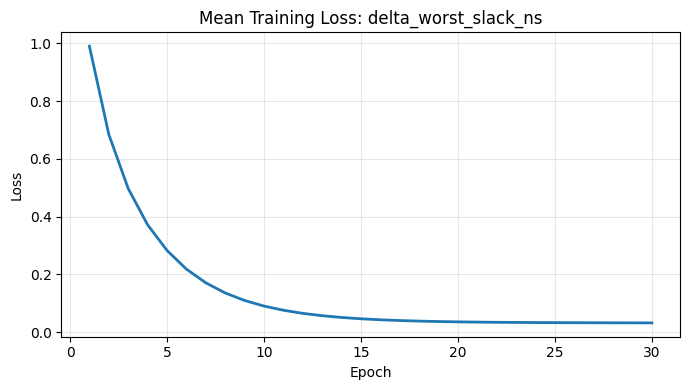

Saved mean training loss plot to ..\results\recipe_improvement_ranking_linear\run_004\mean_training_loss_delta_worst_slack_ns.png


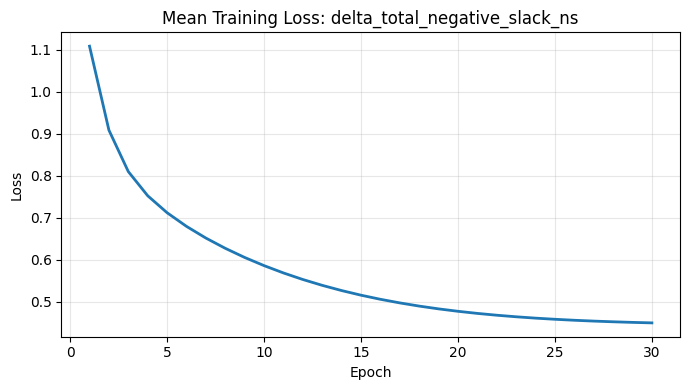

Saved mean training loss plot to ..\results\recipe_improvement_ranking_linear\run_004\mean_training_loss_delta_total_negative_slack_ns.png


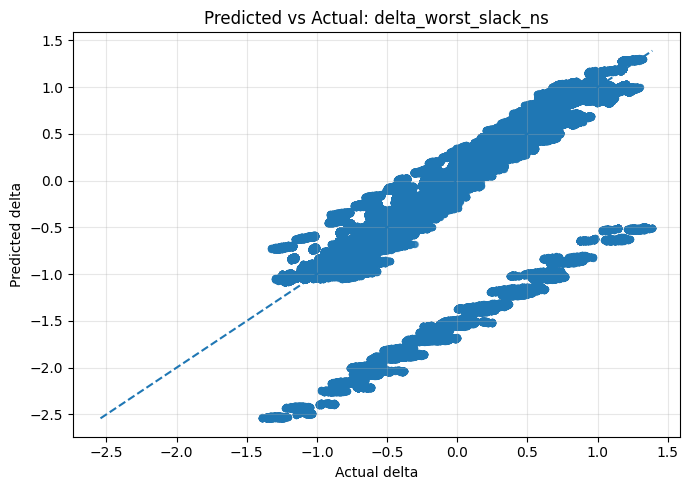

Saved predicted vs actual plot to ..\results\recipe_improvement_ranking_linear\run_004\predicted_vs_actual_delta_worst_slack_ns.png


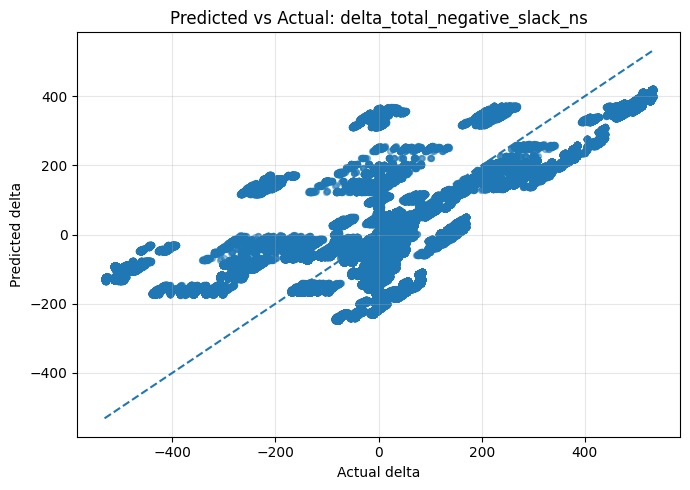

Saved predicted vs actual plot to ..\results\recipe_improvement_ranking_linear\run_004\predicted_vs_actual_delta_total_negative_slack_ns.png


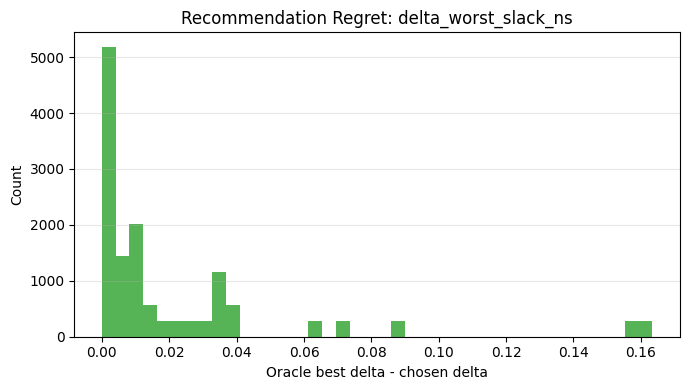

Saved regret histogram to ..\results\recipe_improvement_ranking_linear\run_004\recommendation_regret_delta_worst_slack_ns.png


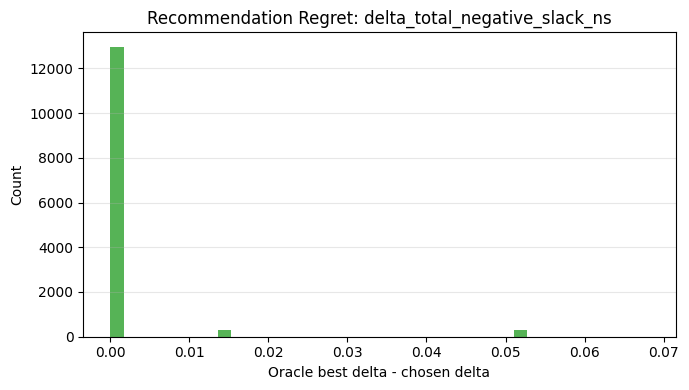

Saved regret histogram to ..\results\recipe_improvement_ranking_linear\run_004\recommendation_regret_delta_total_negative_slack_ns.png


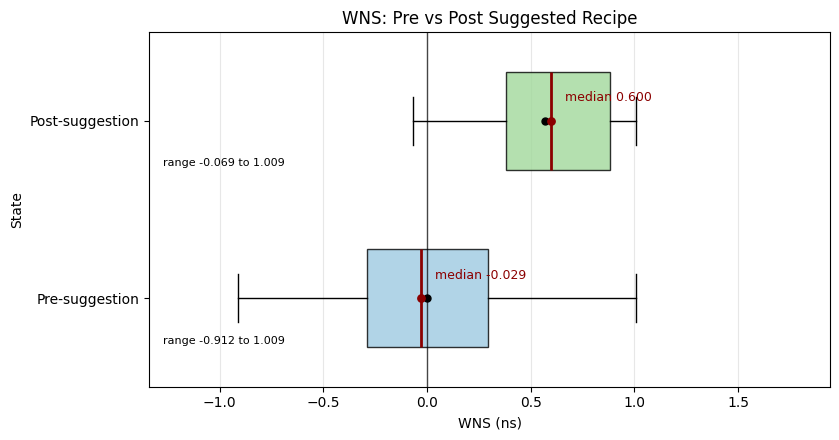

Saved pre/post box plot to ..\results\recipe_improvement_ranking_linear\run_004\pre_vs_post_boxplot_worst_slack_ns.png


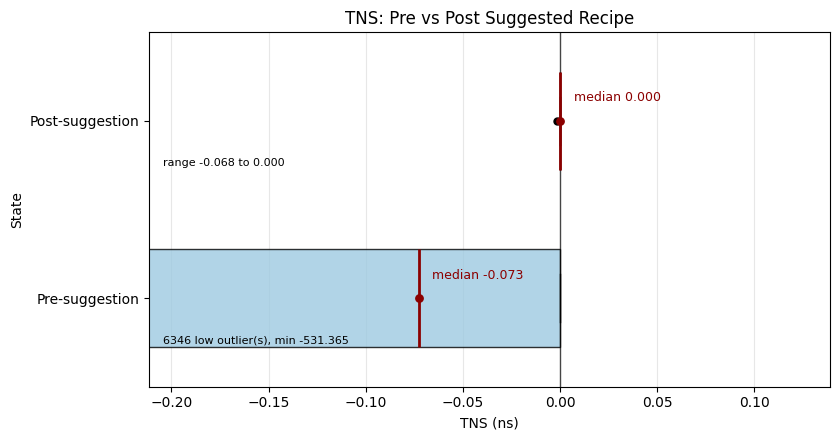

Saved pre/post box plot to ..\results\recipe_improvement_ranking_linear\run_004\pre_vs_post_boxplot_total_negative_slack_ns.png
Saved pre/post summary to ..\results\recipe_improvement_ranking_linear\run_004\pre_post_recommendation_summary.csv
Run summary:


,item,value
0,model_kind,linear
1,target_model_mode,separate_single_output_models
2,split_mode,group_k_fold_design
3,num_folds,5
4,total_base_rows,13536
5,total_designs,47
6,batch_size,4096
7,epochs,30
8,max_train_targets_per_source,16
9,max_test_targets_per_source,None


Fold summary:


,fold,train_rows,test_rows,train_design_count,test_design_count,train_designs,test_designs
0,1,10656,2880,37,10,"i2c, s1196a, s1196b, s1238, s1238a, s13207a, s...","s1196, s13207, s15850, s349, s38584a, s510, s6..."
1,2,10656,2880,37,10,"s1196, s1196a, s1196b, s1238, s13207, s13207a,...","i2c, s1238a, s1488, s344, s38584, s444, s5378a..."
2,3,10944,2592,38,9,"i2c, s1196, s1196a, s1196b, s1238a, s13207, s1...","s1238, s1423a, s298, s38417, s420, s5378, s820..."
3,4,10944,2592,38,9,"i2c, s1196, s1196a, s1238, s1238a, s13207, s13...","s1196b, s1423, s27, s382, s400, s526a, s820, s..."
4,5,10944,2592,38,9,"i2c, s1196, s1196b, s1238, s1238a, s13207, s14...","s1196a, s13207a, s15850a, s35932, s386, s526, ..."


Pair counts:


...

,target,near_oracle_threshold_ns,near_oracle_rate,mean_regret,median_regret
0,delta_worst_slack_ns,0.06,0.8936,0.0211,0.0082
1,delta_total_negative_slack_ns,5.00,1.0000,0.0014,0.0000


Pre/Post suggestion summary:


,metric,pre_mean,post_mean,pre_median,post_median,mean_shift,median_shift
0,WNS,-0.000181,0.570467,-0.028852,0.59951,0.570649,0.628362
1,TNS,-18.236987,-0.001421,-0.072779,0.00000,18.235567,0.072779


Example ranking rows:


,fold,design_name,source_recipe_id,target,chosen_target_recipe_id,oracle_target_recipe_id,chosen_pred_delta,chosen_true_delta,oracle_true_delta,exact_match,improves_over_source,regret
0,1,s1196,abcfast_clk0p1_fo16_tr0p16_cap100_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.003035,0.798063,0.830815,0,1,0.032752
1,1,s1196,abcfast_clk0p1_fo16_tr0p16_cap40_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.007653,0.810020,0.842772,0,1,0.032752
2,1,s1196,abcfast_clk0p1_fo16_tr0p16_cap60_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.003466,0.796776,0.829528,0,1,0.032752
3,1,s1196,abcfast_clk0p1_fo16_tr0p16_cap80_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.003433,0.798063,0.830815,0,1,0.032752
4,1,s1196,abcfast_clk0p1_fo16_tr0p24_cap100_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.002525,0.798063,0.830815,0,1,0.032752
5,1,s1196,abcfast_clk0p1_fo16_tr0p24_cap40_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.007143,0.810020,0.842772,0,1,0.032752
6,1,s1196,abcfast_clk0p1_fo16_tr0p24_cap60_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.002956,0.796776,0.829528,0,1,0.032752
7,1,s1196,abcfast_clk0p1_fo16_tr0p24_cap80_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.002923,0.798063,0.830815,0,1,0.032752
8,1,s1196,abcfast_clk0p1_fo16_tr0p2_cap100_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.002780,0.798063,0.830815,0,1,0.032752
9,1,s1196,abcfast_clk0p1_fo16_tr0p2_cap40_fload1,delta_worst_slack_ns,abcfast_clk1p5_fo64_tr0p24_cap100_fload1,abcfast_clk1p5_fo32_tr0p16_cap60_fload1,1.007398,0.810020,0.842772,0,1,0.032752


In [ ]:
for target_name in DELTA_TARGET_COLUMNS:
    mean_loss_table = (
        loss_history_table[loss_history_table["target"] == target_name]
        .groupby("epoch", as_index=False)["train_loss"]
        .mean()
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(mean_loss_table["epoch"], mean_loss_table["train_loss"], linewidth=2)
    ax.set_title(f"Mean Training Loss: {target_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    loss_plot_path = RUN_DIR / f"mean_training_loss_{target_name}.png"
    fig.savefig(loss_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

for target_idx, target_name in enumerate(DELTA_TARGET_COLUMNS):
    true_vals = all_true[:, target_idx]
    pred_vals = all_pred[:, target_idx]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(true_vals, pred_vals, s=18, alpha=0.45)
    lower = min(true_vals.min(), pred_vals.min())
    upper = max(true_vals.max(), pred_vals.max())
    ax.plot([lower, upper], [lower, upper], linestyle="--", linewidth=1.5)
    ax.set_title(f"Predicted vs Actual: {target_name}")
    ax.set_xlabel("Actual delta")
    ax.set_ylabel("Predicted delta")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    scatter_path = RUN_DIR / f"predicted_vs_actual_{target_name}.png"
    fig.savefig(scatter_path, dpi=200, bbox_inches="tight")
    plt.show()

for target_name in DELTA_TARGET_COLUMNS:
    target_df = ranking_results_table[ranking_results_table["target"] == target_name]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(target_df["regret"], bins=40, color="tab:green", alpha=0.8)
    ax.set_title(f"Recommendation Regret: {target_name}")
    ax.set_xlabel("Oracle best delta - chosen delta")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    regret_path = RUN_DIR / f"recommendation_regret_{target_name}.png"
    fig.savefig(regret_path, dpi=200, bbox_inches="tight")
    plt.show()

metric_plot_map = {
    "delta_worst_slack_ns": ("worst_slack_ns", "WNS"),
    "delta_total_negative_slack_ns": ("total_negative_slack_ns", "TNS"),
}

source_metric_lookup = rows_df[["design_name", "recipe_id"] + QOR_COLUMNS].copy()
source_metric_lookup = source_metric_lookup.rename(columns={"recipe_id": "source_recipe_id"})

pre_post_summary_rows = []
for target_name, (metric_col, metric_label) in metric_plot_map.items():
    target_df = ranking_results_table[ranking_results_table["target"] == target_name].copy()
    target_df = target_df.merge(
        source_metric_lookup[["design_name", "source_recipe_id", metric_col]],
        on=["design_name", "source_recipe_id"],
        how="left",
    )
    target_df = target_df.rename(columns={metric_col: "source_metric"})
    target_df = target_df.dropna(subset=["source_metric"]).copy()
    target_df["chosen_metric"] = target_df["source_metric"] + target_df["chosen_true_delta"]

    pre_values = target_df["source_metric"].astype(float).to_numpy()
    post_values = target_df["chosen_metric"].astype(float).to_numpy()

    all_values = np.concatenate([pre_values, post_values])
    q1 = float(np.quantile(all_values, 0.25))
    q3 = float(np.quantile(all_values, 0.75))
    iqr = q3 - q1
    if iqr == 0:
        iqr = max(1e-6, abs(q3) * 0.1 + 1e-6)
    display_low = q1 - 1.5 * iqr
    display_high = q3 + 1.5 * iqr
    padding = max(0.03, 0.08 * (display_high - display_low))
    x_min = display_low - padding
    x_max = display_high + padding

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    box = ax.boxplot(
        [pre_values, post_values],
        tick_labels=["Pre-suggestion", "Post-suggestion"],
        patch_artist=True,
        widths=0.55,
        showmeans=True,
        showfliers=False,
        vert=False,
        medianprops={"color": "darkred", "linewidth": 2.0},
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 5},
    )
    for patch, color in zip(box["boxes"], ["#9ecae1", "#a1d99b"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    pre_median = float(np.median(pre_values))
    post_median = float(np.median(post_values))
    pre_min = float(np.min(pre_values))
    pre_max = float(np.max(pre_values))
    post_min = float(np.min(post_values))
    post_max = float(np.max(post_values))
    pre_low_outliers = int(np.sum(pre_values < x_min))
    pre_high_outliers = int(np.sum(pre_values > x_max))
    post_low_outliers = int(np.sum(post_values < x_min))
    post_high_outliers = int(np.sum(post_values > x_max))

    ax.scatter([pre_median], [1], color="darkred", s=28, zorder=4)
    ax.scatter([post_median], [2], color="darkred", s=28, zorder=4)
    ax.text(pre_median + 0.02 * (x_max - x_min), 1.13, f"median {pre_median:.3f}", color="darkred", ha="left", va="center", fontsize=9)
    ax.text(post_median + 0.02 * (x_max - x_min), 2.13, f"median {post_median:.3f}", color="darkred", ha="left", va="center", fontsize=9)

    pre_note_lines = []
    if pre_low_outliers > 0:
        pre_note_lines.append(f"{pre_low_outliers} low outlier(s), min {pre_min:.3f}")
    if pre_high_outliers > 0:
        pre_note_lines.append(f"{pre_high_outliers} high outlier(s), max {pre_max:.3f}")
    if not pre_note_lines:
        pre_note_lines.append(f"range {pre_min:.3f} to {pre_max:.3f}")

    post_note_lines = []
    if post_low_outliers > 0:
        post_note_lines.append(f"{post_low_outliers} low outlier(s), min {post_min:.3f}")
    if post_high_outliers > 0:
        post_note_lines.append(f"{post_high_outliers} high outlier(s), max {post_max:.3f}")
    if not post_note_lines:
        post_note_lines.append(f"range {post_min:.3f} to {post_max:.3f}")

    ax.text(x_min + 0.02 * (x_max - x_min), 0.76, "\n".join(pre_note_lines), ha="left", va="center", fontsize=8)
    ax.text(x_min + 0.02 * (x_max - x_min), 1.76, "\n".join(post_note_lines), ha="left", va="center", fontsize=8)
    ax.axvline(0.0, color="black", linewidth=1.0, alpha=0.7)
    ax.set_title(f"{metric_label}: Pre vs Post Suggested Recipe")
    ax.set_xlabel(f"{metric_label} (ns)")
    ax.set_ylabel("State")
    ax.set_xlim(x_min, x_max)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    boxplot_path = RUN_DIR / f"pre_vs_post_boxplot_{metric_col}.png"
    fig.savefig(boxplot_path, dpi=200, bbox_inches="tight")
    plt.show()

    pre_post_summary_rows.append({
        "metric": metric_label,
        "pre_mean": float(np.mean(pre_values)),
        "post_mean": float(np.mean(post_values)),
        "pre_median": pre_median,
        "post_median": post_median,
        "mean_shift": float(np.mean(post_values) - np.mean(pre_values)),
        "median_shift": float(post_median - pre_median),
    })

pre_post_summary_table = pd.DataFrame(pre_post_summary_rows)
pre_post_summary_path = RUN_DIR / "pre_post_recommendation_summary.csv"
pre_post_summary_table.to_csv(pre_post_summary_path, index=False)

near_oracle_table = ranking_summary_table[[
    "target",
    "near_oracle_threshold_ns",
    "near_oracle_rate",
    "mean_regret",
    "median_regret",
]].copy()

run_summary_table = pd.DataFrame([
    {"item": "model_kind", "value": MODEL_KIND},
    {"item": "target_model_mode", "value": "separate_single_output_models"},
    {"item": "split_mode", "value": "group_k_fold_design"},
    {"item": "num_folds", "value": n_splits},
    {"item": "total_base_rows", "value": len(rows_df)},
    {"item": "total_designs", "value": len(unique_designs)},
    {"item": "batch_size", "value": BATCH_SIZE},
    {"item": "epochs", "value": EPOCHS},
    {"item": "max_train_targets_per_source", "value": MAX_TRAIN_TARGETS_PER_SOURCE},
    {"item": "max_test_targets_per_source", "value": MAX_TEST_TARGETS_PER_SOURCE},
])

print("Run summary:")
display(run_summary_table)

print("Fold summary:")
display(fold_info_table)

print("Pair counts:")
display(pair_count_table)

print("Pair regression summary:")
display(regression_summary_table)

print("Recipe ranking summary:")
display(ranking_summary_table)

print("Near-oracle summary:")
display(near_oracle_table)

print("Pre/Post suggestion summary:")
display(pre_post_summary_table)

print("Example ranking rows:")
display(ranking_results_table.head(20))

